Build classification and Regression Model

Planning to remove late_canc_reason, from_actual_arrival_min , from_actual_departure_min , to_actual_arrival_min,  to_actual_departure_min, propagated_delay_min, end_segment_delay_min, cum_delay_min , prev_train_leg_delay_min , prev_train_cum_delay_min , prev_train_end_segment_delay_min , historical_avg_propagated_delay_min , historical_avg_cum_delay_min , historical_avg_arrival_delay_min , delay_historical_difference


---

Removing this because they will result in the model overfitting the training dataset as these information wont be availabvle

From arrival delay col dodf["delayed"] = (df["arrival_delay_min"] >= 10).astype(int)

In [230]:
import pandas as pd
import plotly.express as px
import numpy as np

In [231]:
pd.set_option('display.float_format', '{:.2f}'.format)
df = pd.read_csv("Datasets/final-segment-dataset-2025.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11195 entries, 0 to 11194
Data columns (total 38 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   rid                                  11195 non-null  float64
 1   from_station                         11195 non-null  object 
 2   to_station                           11195 non-null  object 
 3   late_canc_reason                     3721 non-null   float64
 4   total_stops_in_run                   11195 non-null  int64  
 5   remaining_stops_after_this           11195 non-null  int64  
 6   date_of_service                      11195 non-null  object 
 7   month                                11195 non-null  int64  
 8   day_of_week                          11195 non-null  int64  
 9   day_of_month                         11195 non-null  int64  
 10  from_sched_arrival_min               11195 non-null  int64  
 11  from_actual_arrival_min     

In [232]:
df.shape

(11195, 38)

In [233]:
#numerical columns
df.describe()

,rid,late_canc_reason,total_stops_in_run,remaining_stops_after_this,month,day_of_week,day_of_month,from_sched_arrival_min,from_actual_arrival_min,from_sched_departure_min,...,historical_avg_leg_duration_min,historical_avg_cum_delay_min,historical_avg_arrival_delay_min,delay_historical_difference,from_temp,from_precip,from_wind,to_temp,to_precip,to_wind
count,11195.00,3721.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,...,11136.00,11136.00,11136.00,11136.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00
mean,202506392764627.06,765.55,9.16,4.58,6.39,1.99,15.60,1042.49,1033.37,1187.20,...,28.82,-187.20,-61.54,41.83,11.40,0.06,12.28,10.77,0.06,12.24
std,3394574883.53,134.35,2.30,2.69,3.39,1.42,8.70,420.57,438.03,105.65,...,27.15,126.15,35.68,143.14,6.69,0.35,6.92,6.32,0.36,7.35
min,202501000000000.00,501.00,4.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,...,-115.86,-1069.00,-189.44,-1265.00,-26.80,0.00,0.00,-26.80,0.00,0.00
25%,202503000000000.00,650.00,6.00,2.00,3.00,1.00,8.00,1112.00,1113.00,1127.00,...,13.20,-253.16,-76.52,32.57,6.60,0.00,7.20,6.30,0.00,6.80
50%,202506000000000.00,828.00,10.00,4.00,6.00,2.00,16.00,1187.00,1195.00,1194.00,...,23.37,-179.30,-60.26,53.84,11.60,0.00,11.30,11.00,0.00,11.00
75%,202509000000000.00,887.00,11.00,7.00,9.00,3.00,23.00,1257.00,1262.00,1259.00,...,37.04,-89.43,-30.94,67.59,15.80,0.00,16.00,15.00,0.00,16.20
max,202512000000000.00,921.00,14.00,13.00,12.00,4.00,31.00,1391.00,1438.00,1391.00,...,1195.00,132.00,66.00,1133.00,32.40,7.20,60.10,31.50,7.20,61.20


In [234]:
#Creating target variable
df["Delayed"] = (df["arrival_delay_min"] >= 10).astype(int)

In [235]:
features = ["from_temp", "to_temp", "from_precip", "to_precip", "from_wind", "to_wind", "prev_train_leg_delay_min",
"prev_train_cum_delay_min",
"prev_train_segment_duration_min",
"prev_train_end_segment_delay_min",
"historical_avg_propagated_delay_min",
"historical_avg_leg_duration_min",
"historical_avg_cum_delay_min",
"historical_avg_arrival_delay_min",
"to_sched_arrival_min",
"to_sched_departure_min",
"day_of_week"]



In [236]:
# Potential features to use


for feature in features:
    outlier_identifier = px.histogram(df, x=feature)
    outlier_identifier.show()

Classification Model part

---



In [237]:
#To construct and plot decision trees
from sklearn import tree
from matplotlib import pyplot as plt

#Import Decision Tree Classifier to predict loan approval status
from sklearn.tree import DecisionTreeClassifier


#To optimise the Decision Tree model's hyperparameters
from sklearn.model_selection import GridSearchCV

#Import scikit-learn metrics module for classification and regression performance metrics
from sklearn import metrics

# To create and plot the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# To produce the classification metrics report
from sklearn.metrics import classification_report

# To create, calculate and plot the RoC curve
from sklearn.metrics import RocCurveDisplay


In [238]:
#Splitting into X and Y

columns_to_drop = ["Delayed", "delay_historical_difference", "arrival_delay_min", "leg_duration_min",
                   "cum_delay_min", "end_segment_delay_min", "to_actual_arrival_min", "to_actual_departure_min", 
                   "from_actual_departure_min", "from_actual_arrival_min", "date_of_service", "late_canc_reason", "from_station", "to_station",
                   "rid", "propagated_delay_min", "prev_train_leg_delay_min", "prev_train_cum_delay_min", "prev_train_segment_duration_min", 
                   "historical_avg_propagated_delay_min", "historical_avg_leg_duration_min", "historical_avg_cum_delay_min"]

X = df.drop(columns=columns_to_drop)
y = df["Delayed"]


In [239]:
from sklearn.model_selection import train_test_split

# Split the dataset in 80% Training and 20% Test with class stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [240]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaler = scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [241]:
print('Whole Data shape', df.shape)
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)


Whole Data shape (11195, 39)
X_train shape (8956, 17)
X_test shape (2239, 17)


In [242]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):

  """
  Function evaluates the model by making predictions, printing the classification report, confusion matrix,
  and ROC curve.

  Returns test and train predictions

  """

  y_pred_train = model.predict(X_train) # Model predictions on training data 
  y_pred = model.predict(X_test) # Model predictions on test data 
  
  target_names = ['Not Delayed', 'Delayed'] # Define custom labels for classes 0 and 1 to make it easier to interpret

  print(f"\n{model_name} Classification report\n")
  print(classification_report(y_test, y_pred, target_names=target_names)) # Prints the Classification report with custom labels 

  cm = confusion_matrix(y_test, y_pred, labels = model.classes_) # Create confusion matrix 
  disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = target_names) # Visualises confusion matrix with custom labels 

  disp.plot() # Displays the confusion matrix 
  disp.ax_.set_title(f"{model_name} Confusion Matrix") # Titles graph 

  roc = RocCurveDisplay.from_estimator(model, X_test, y_test, name="Delayed Class") # Displays Roc Curve 
  roc.ax_.set_title(f"{model_name} ROC Curve") # Titles graph 



  return y_pred, y_pred_train # Returns y test and train predictions


Fully Grown Decision Tree Classification report

              precision    recall  f1-score   support

 Not Delayed       0.87      0.86      0.86      1790
     Delayed       0.46      0.47      0.46       449

    accuracy                           0.78      2239
   macro avg       0.66      0.66      0.66      2239
weighted avg       0.78      0.78      0.78      2239



(array([0, 0, 0, ..., 0, 0, 0], shape=(2239,)),
 array([0, 0, 0, ..., 0, 1, 1], shape=(8956,)))

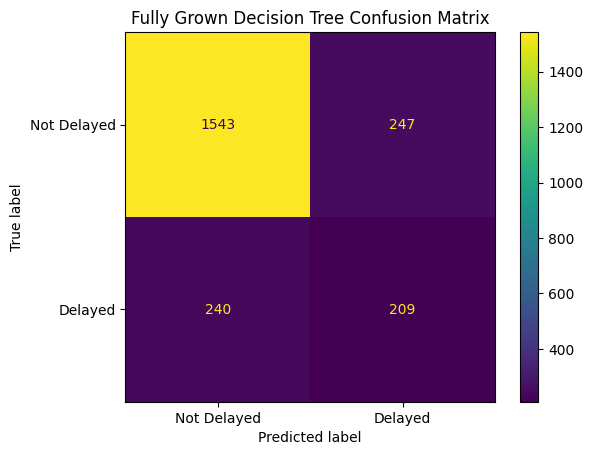

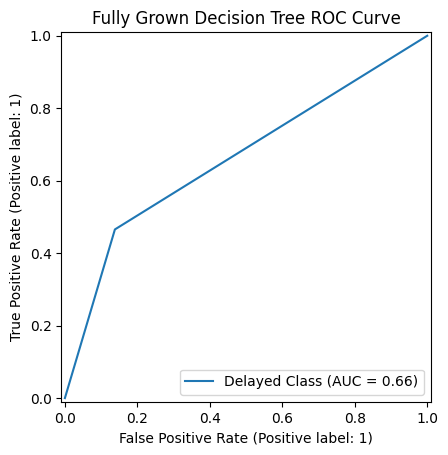

In [243]:
# Build a fully grown decision tree clf
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

#To make predictions on the test set, ues the predict method:
y_pred_clf = clf.predict(X_test)


# Prints metrics for evaluation

evaluate_model(clf, "Fully Grown Decision Tree", X_train, X_test, y_train, y_test)


Logistic Regression Classification report

              precision    recall  f1-score   support

 Not Delayed       0.84      0.52      0.65      1790
     Delayed       0.24      0.60      0.34       449

    accuracy                           0.54      2239
   macro avg       0.54      0.56      0.49      2239
weighted avg       0.72      0.54      0.58      2239



(array([0, 1, 0, ..., 1, 1, 1], shape=(2239,)),
 array([0, 1, 1, ..., 1, 0, 1], shape=(8956,)))

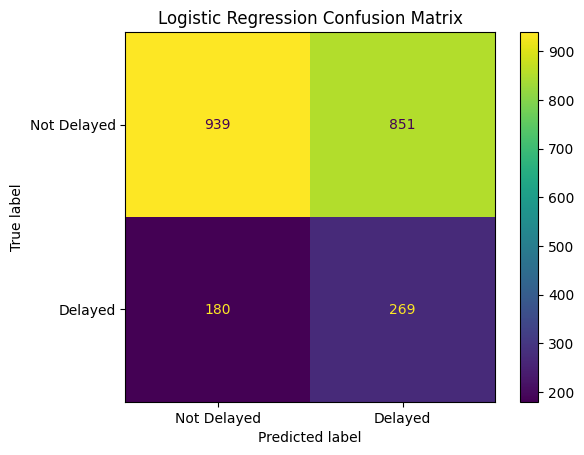

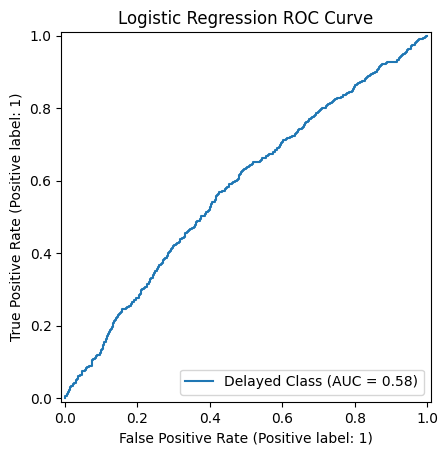

In [244]:
from sklearn.linear_model import LogisticRegression

# Build a fully grown decision tree clf
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

#To make predictions on the test set, ues the predict method:
y_pred_lr = lr.predict(X_test)


# Prints metrics for evaluation

evaluate_model(lr, "Logistic Regression", X_train, X_test, y_train, y_test)



K-Nearest Neighbors Classification report

              precision    recall  f1-score   support

 Not Delayed       0.83      0.94      0.88      1790
     Delayed       0.50      0.23      0.32       449

    accuracy                           0.80      2239
   macro avg       0.67      0.59      0.60      2239
weighted avg       0.76      0.80      0.77      2239



(array([1, 0, 0, ..., 0, 0, 0], shape=(2239,)),
 array([0, 0, 0, ..., 0, 1, 1], shape=(8956,)))

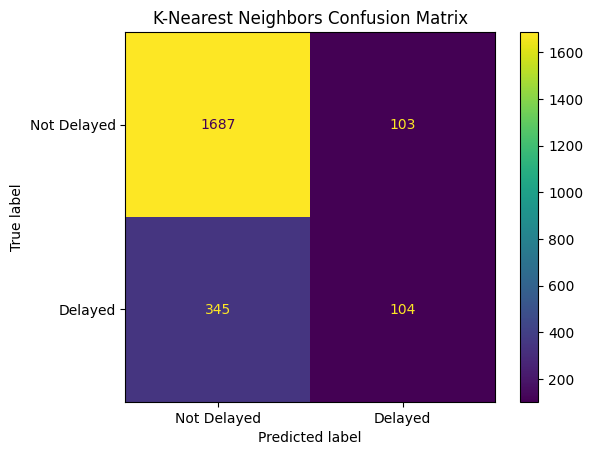

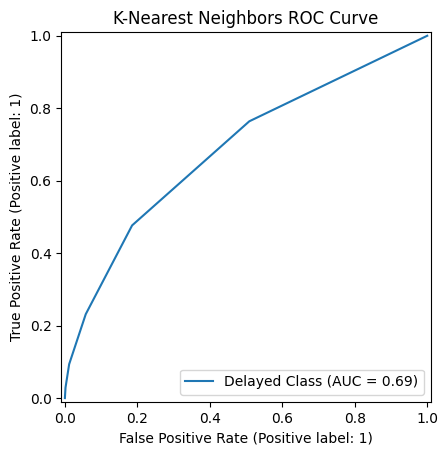

In [245]:
from sklearn.neighbors import KNeighborsClassifier

# Build a fully grown decision tree clf
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

#To make predictions on the test set, ues the predict method:
y_pred_knn = knn.predict(X_test)


# Prints metrics for evaluation

evaluate_model(knn, "K-Nearest Neighbors", X_train, X_test, y_train, y_test)


XGBoost Classification report

              precision    recall  f1-score   support

 Not Delayed       0.86      0.96      0.91      1790
     Delayed       0.70      0.40      0.51       449

    accuracy                           0.85      2239
   macro avg       0.78      0.68      0.71      2239
weighted avg       0.83      0.85      0.83      2239



(array([0, 0, 0, ..., 0, 0, 0], shape=(2239,)),
 array([0, 0, 0, ..., 0, 1, 1], shape=(8956,)))

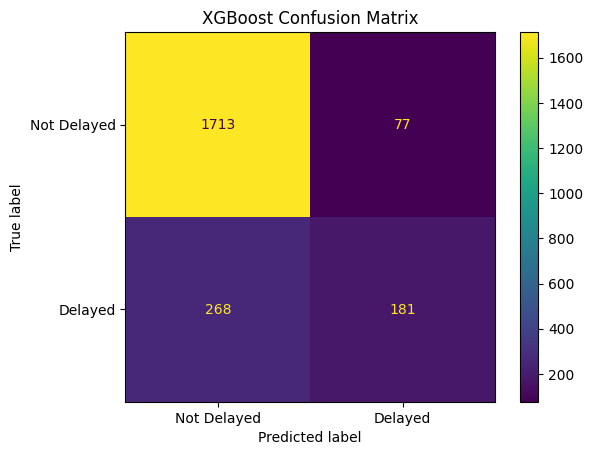

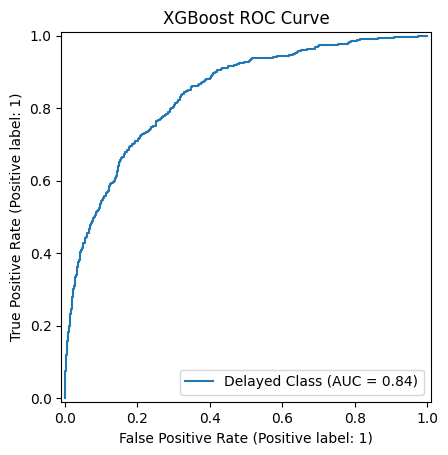

In [246]:
from xgboost import XGBClassifier

# Build a fully grown decision tree clf
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

#To make predictions on the test set, ues the predict method:
y_pred_xgb = xgb.predict(X_test)


# Prints metrics for evaluation

evaluate_model(xgb, "XGBoost", X_train, X_test, y_train, y_test)

[LightGBM] [Info] Number of positive: 1795, number of negative: 7161
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1669
[LightGBM] [Info] Number of data points in the train set: 8956, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200424 -> initscore=-1.383645
[LightGBM] [Info] Start training from score -1.383645

LightGBM Classification report

              precision    recall  f1-score   support

 Not Delayed       0.85      0.97      0.91      1790
     Delayed       0.73      0.33      0.45       449

    accuracy                           0.84      2239
   macro avg       0.79      0.65      0.68      2239
weighted avg       0.83      0.84      0.82      2239



C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserW

(array([0, 0, 0, ..., 0, 0, 0], shape=(2239,)),
 array([0, 0, 0, ..., 0, 1, 0], shape=(8956,)))

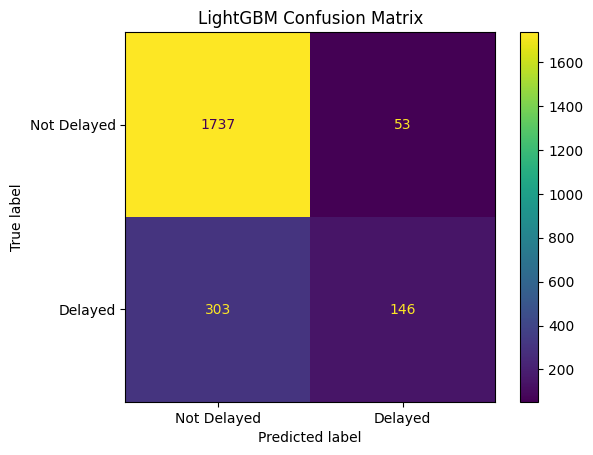

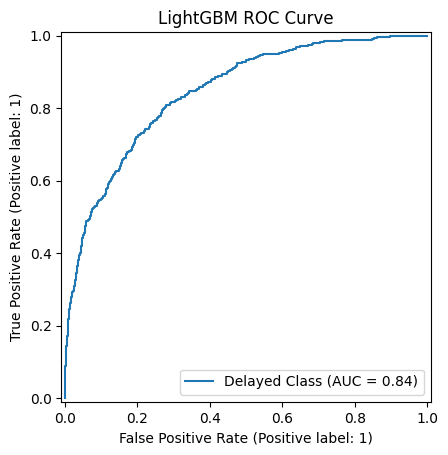

In [247]:
from lightgbm import LGBMClassifier

# Build a fully grown decision tree clf
gbm = LGBMClassifier()
gbm.fit(X_train, y_train)

#To make predictions on the test set, ues the predict method:
y_pred_gbm = gbm.predict(X_test)


# Prints metrics for evaluation

evaluate_model(gbm, "LightGBM", X_train, X_test, y_train, y_test)

XGBoost and LightGBM performed much better than others so will tune hyperparameter

In [248]:

# Split the dataset in 80% Training and 20% Test with class stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

Best hyperparameters: {'colsample_bytree': 0.7, 'gamma': 5, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}

Tuned XGBoost Classification report

              precision    recall  f1-score   support

 Not Delayed       0.80      1.00      0.89      1790
     Delayed       0.89      0.02      0.03       449

    accuracy                           0.80      2239
   macro avg       0.85      0.51      0.46      2239
weighted avg       0.82      0.80      0.72      2239



(array([0, 0, 0, ..., 0, 0, 0], shape=(2239,)),
 array([0, 0, 0, ..., 0, 1, 0], shape=(8956,)))

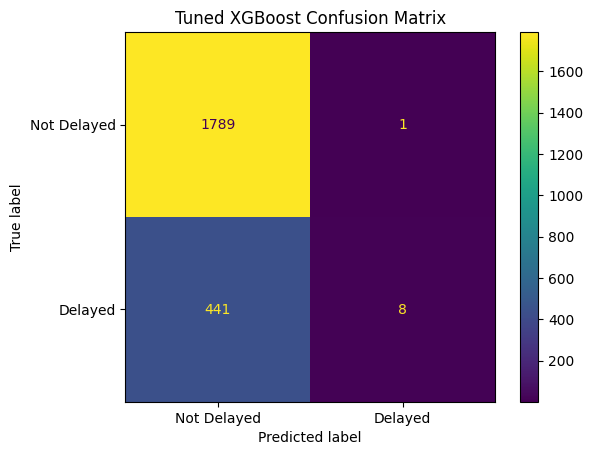

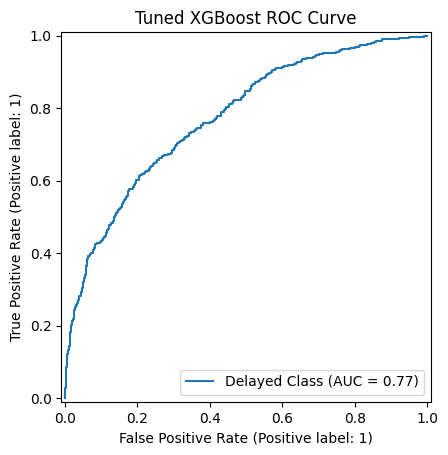

In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],        # number of trees
    'max_depth': [3, 5, 7],                 # maximum tree depth
    'learning_rate': [0.01, 0.1, 0.2],     # step size shrinkage
    'subsample': [0.7, 0.8, 1.0],          # fraction of samples used per tree
    'colsample_bytree': [0.7, 0.8, 1.0],   # fraction of features used per tree
    'gamma': [0, 1, 5],                     # minimum loss reduction to make split
}

xgb = XGBClassifier(eval_metric='logloss', random_state=123)

# Initialize GridSearchCV
gscv = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',          # choose metric depending on your goal
    cv=5,                  # 5-fold cross-validation
    n_jobs=-1             # use all cores

)


# Build a fully grown decision tree clf

gscv.fit(X_train, y_train)

best_xgb = gscv.best_estimator_
print("Best hyperparameters:", gscv.best_params_)

# Prints metrics for evaluation

evaluate_model(best_xgb, "Tuned XGBoost", X_train, X_test, y_train, y_test)

Best hyperparameters: {'colsample_bytree': 0.7, 'gamma': 5, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}

Tuned LightGBM Classification report

              precision    recall  f1-score   support

 Not Delayed       0.80      1.00      0.89      1790
     Delayed       0.89      0.02      0.03       449

    accuracy                           0.80      2239
   macro avg       0.85      0.51      0.46      2239
weighted avg       0.82      0.80      0.72      2239



(array([0, 0, 0, ..., 0, 0, 0], shape=(2239,)),
 array([0, 0, 0, ..., 0, 1, 0], shape=(8956,)))

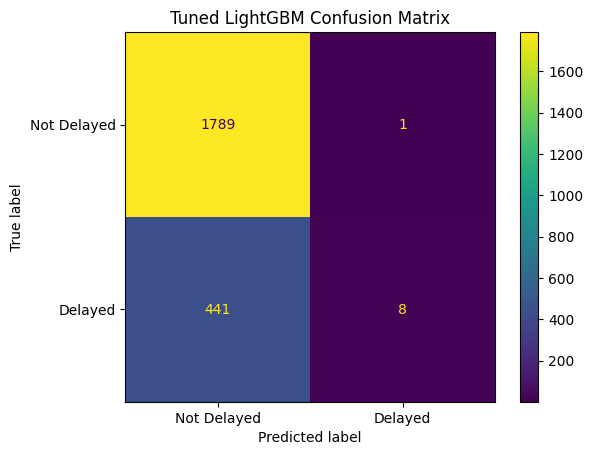

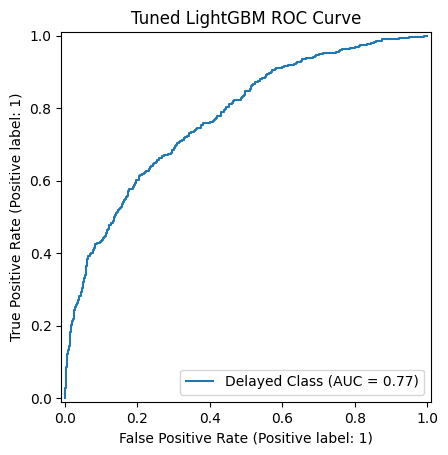

In [ ]:


# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}

# Initialize LightGBM 
gbm = LGBMClassifier(         
    random_state=123
)

# Set up GridSearchCV
gscv_search = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    scoring='f1',           # choose your metric
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to training data
gscv.fit(X_train, y_train)

# Get best model
best_gbm = gscv.best_estimator_
print("Best hyperparameters:", gscv.best_params_)


# Evaluate performance
evaluate_model(best_gbm, "Tuned LightGBM", X_train, X_test, y_train, y_test)

LightGBM will be used based on speed and potential dataset size exploding in real world scenario

In [251]:

columns_to_drop = ["Delayed", "delay_historical_difference", "arrival_delay_min", "leg_duration_min",
                   "cum_delay_min", "end_segment_delay_min", "to_actual_arrival_min", "to_actual_departure_min", 
                   "from_actual_departure_min", "from_actual_arrival_min", "date_of_service", "late_canc_reason", "from_station", "to_station",
                   "rid", "propagated_delay_min", "prev_train_leg_delay_min", "prev_train_cum_delay_min", "prev_train_segment_duration_min", 
                   "historical_avg_propagated_delay_min", "historical_avg_leg_duration_min", "historical_avg_cum_delay_min"]

X = df.drop(columns=columns_to_drop)
y = df["Delayed"]

# Split the dataset in 80% Training and 20% Test with class stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [252]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [7, 15],          # keep reasonable depth
    'learning_rate': [0.01, 0.05],     
    'num_leaves': [31, 50],           
    'subsample': [0.5, 0.6, 0.7],          # row sampling
    'feature_fraction': [0.5, 0.6, 0.7],   # column sampling
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 0.1],
    'min_child_samples': [10, 20],    # prevents overfitting on small leaves
}

# Initialize classifier with random_state for reproducibility
gbm = LGBMClassifier(
    random_state=123,
    device='gpu'      # Use GPU if available
)


# Set up GridSearchCV
gscv = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    scoring='precision',      
    cv=5,
    n_jobs=-1,
    verbose=2,
)


# Fit to training data
gscv.fit(X_train, y_train)

# Best model
best_gbm = gscv.best_estimator_
print("Best hyperparameters:", gscv.best_params_)

# Evaluate performance
evaluate_model(best_gbm, "Precision Tuned LightGBM", X_train, X_test, y_train, y_test)

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits


KeyboardInterrupt: 

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [7, 15],          # keep reasonable depth
    'learning_rate': [0.01, 0.05],     
    'num_leaves': [31, 50],           
    'subsample': [0.5, 0.6, 0.7],          # row sampling
    'feature_fraction': [0.5, 0.6, 0.7],   # column sampling
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 0.1],
    'min_child_samples': [10, 20],    # prevents overfitting on small leaves
}

# Initialize classifier with random_state for reproducibility
gbm = LGBMClassifier(
    random_state=123,
    device='gpu'      # Use GPU if available
)


# Set up GridSearchCV
gscv = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    scoring='recall',      
    cv=5,
    n_jobs=-1,
    verbose=2,
)


# Fit to training data
gscv.fit(X_train, y_train)

# Best model
best_gbm = gscv.best_estimator_
print("Best hyperparameters:", gscv.best_params_)

# Evaluate performance
evaluate_model(best_gbm, "Recall Tuned LightGBM", X_train, X_test, y_train, y_test)